<a href="https://colab.research.google.com/github/ayushmant908-web/machine_learning-100-Days/blob/main/sigmoid_function_in_logistic_rergression_ml_day_58.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [145]:
from sklearn.datasets import make_classification
import numpy as np
import matplotlib.pyplot as plt

In [146]:
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=30)

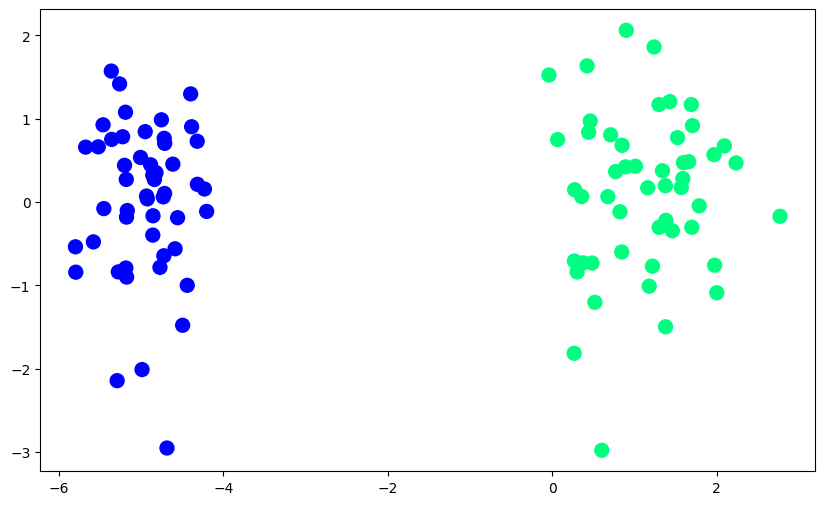

In [147]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [148]:
def precpton(X,y):

  X=np.insert(X,0,1,axis=1)
  weights=np.ones(X.shape[1])
  lr=0.1

  for i in range(1000):
    j=np.random.randint(0,100)
    y_hat=step(np.dot(X[j],weights))
    weights=weights+lr*(y[j]-y_hat)*X[j]

  return weights[0],weights[1:]

In [149]:
def step(z):
  return 1 if z>0 else 0

In [150]:
intercept_,coef_=precpton(X,y)

In [151]:
print(coef_)
print(intercept_)

[1.1134548  0.33857969]
1.3000000000000003


In [152]:
m=-(coef_[0]/coef_[1])
b=-(intercept_/coef_[1])

In [153]:
x_input=np.linspace(3,-3,100)
y_input=m*x_input+b

(-3.0, 2.0)

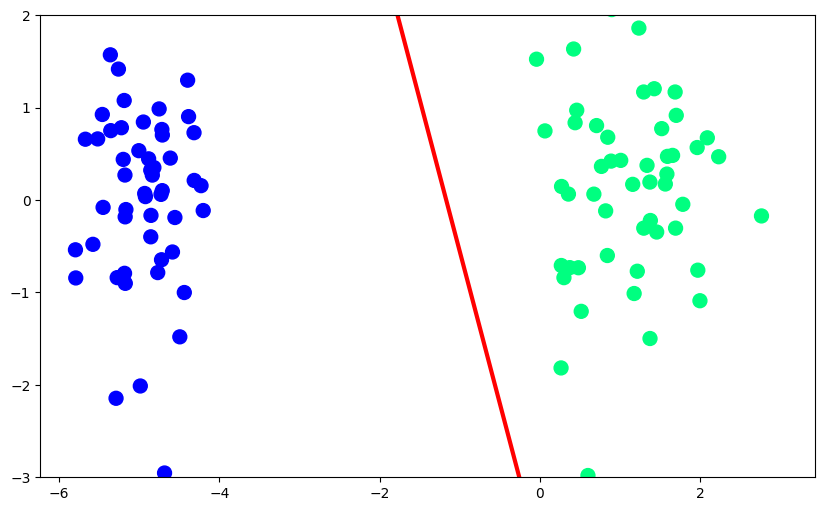

In [154]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

In [155]:
from sklearn.linear_model import LogisticRegression

In [156]:
lor=LogisticRegression()

In [157]:
lor.fit(X,y)

LogisticRegression()

In [158]:
m=-(lor.coef_[0][0]/lor.coef_[0][1])
b = -(lor.intercept_/lor.coef_[0][1])

In [159]:
x_input1=np.linspace(-3,3,100)
y_input1=m*x_input1+b

(-3.0, 2.0)

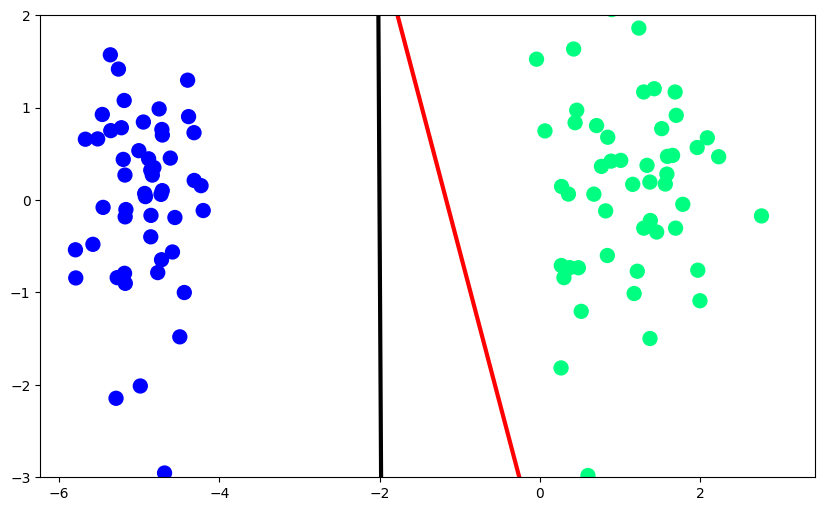

In [160]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

In [161]:
def precpton(X,y):

  X=np.insert(X,0,1,axis=1)
  weights=np.ones(X.shape[1])
  lr=0.1

  for i  in range (1000):
    j=np.random.randint(0,100)
    y_hat=sigmoid(np.dot(X[j],weights))
    weights=weights+lr*(y[j]-y_hat)*X[j]

  return weights[0],weights[1:]

In [162]:
def sigmoid(z):
  return (1/(1+np.exp (-z)))

In [163]:
intercept_,coef_=precpton(X,y)

In [164]:
x_input2=np.linspace(-3,3,100)
y_input2=m*x_input2+b

(-3.0, 2.0)

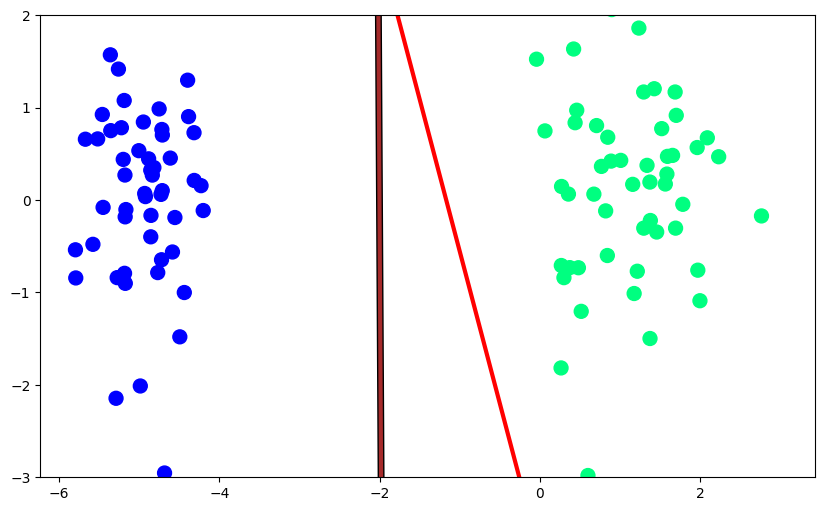

In [165]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=5)
plt.plot(x_input2,y_input2,color='brown',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

In [166]:
def perceptron(X,y):

    m = []
    b = []

    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1

    for i in range(200):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]

        m.append(-(weights[1]/weights[2]))
        b.append(-(weights[0]/weights[2]))

    return m,b

In [167]:
m,b=precpton(X,y)

In [168]:
%matplotlib inline
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

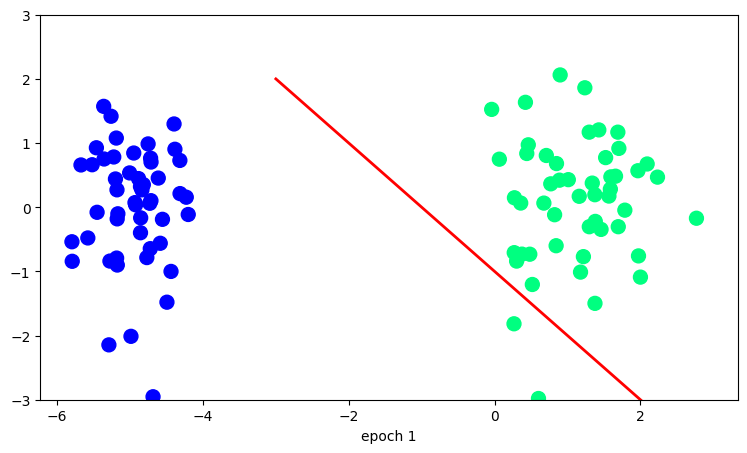

In [169]:
m, b = perceptron(X, y)

fig, ax = plt.subplots(figsize=(9,5))

x_i = np.arange(-3, 3, 0.1)
y_i = x_i*m[0] + b[0]
ax.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
line, = ax.plot(x_i, x_i*m[0] + b[0] , 'r-', linewidth=2)
plt.ylim(-3,3)

def update(i):
    label = 'epoch {0}'.format(i + 1)
    line.set_ydata(x_i*m[i] + b[i])
    ax.set_xlabel(label)
    return line, ax

anim = FuncAnimation(fig, update, repeat=True, frames=200, interval=100)